In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from xgboost import XGBClassifier


In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 17)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1,age1_tminus1,income1_tminus1,job1_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0,43,7,1
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0,44,8,1
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0,45,8,1
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,46,9,1
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,47,9,1


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


In [3]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 서비스 가입 여부",
    "a03026_tminus1": "데이터 무제한 서비스 가입 여부",
    "c01002_tminus1": "월평균 휴대폰 이용 총 금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "휴대폰 결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 월평균 소득",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))

In [4]:
# ============================================================
# 3. churn_to_mvno 분석용 데이터 구성
# ============================================================
# churn_to_mvno는 "메이저(1/2/3) -> MVNO(4)"만 1이므로,
# 해석상 전년 통신사가 메이저였던 사람들만 대상으로 보는 것이 자연스럽다.
#
# 단, 현재 저장된 데이터에 telco_tminus1 같은 컬럼이 없다면
# 전체 데이터에서 그대로 진행해야 한다.
# 여기서는 우선 현재 컬럼 기준으로 안전하게 진행한다.

target_col = "churn_to_mvno"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

# 혹시 telco 관련 컬럼이 있으면 누수 방지를 위해 제외
possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols
drop_cols = list(dict.fromkeys(drop_cols))

feature_cols = [col for col in df.columns if col not in drop_cols]

print("사용 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)
print("churn_to_mvno 비율:", df[target_col].mean())
print("양성 개수:", df[target_col].sum())

사용 feature 개수: 10
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']
churn_to_mvno 비율: 0.012470035594082182
양성 개수: 515


In [5]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("양성 비율:", y.mean())
print("고유 pid 수:", groups.nunique())

X shape: (41299, 10)
양성 비율: 0.012470035594082182
고유 pid 수: 10071


In [6]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train 양성 비율:", y_train.mean())
print("Test 양성 비율 :", y_test.mean())
print("Train 양성 개수:", y_train.sum())
print("Test 양성 개수 :", y_test.sum())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))

Train shape: (32992, 10)
Test shape : (8307, 10)
Train 양성 비율: 0.013063773035887488
Test 양성 비율 : 0.010111953773925604
Train 양성 개수: 431
Test 양성 개수 : 84
겹치는 pid 수: 0


In [7]:
# ============================================================
# 6. 평가 함수
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

In [8]:
# ============================================================
# 7. Logistic Regression 학습
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]

In [9]:
# ============================================================
# 8. Random Forest 학습
# ============================================================
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

In [10]:
# ============================================================
# 추가. Decision Tree / Gradient Boosting 학습
# ============================================================
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_proba_dt = dt_pipe.predict_proba(X_test)[:, 1]

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]


xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

In [11]:
# ============================================================
# 9. 성능 비교
# ============================================================
result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")
result_dt = evaluate_binary_classifier(y_test, y_pred_dt, y_proba_dt, "DecisionTree")
result_gb = evaluate_binary_classifier(y_test, y_pred_gb, y_proba_gb, "GradientBoosting")

result_xgb = evaluate_binary_classifier(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

result_df = pd.DataFrame([result_log, result_rf, result_dt, result_gb, result_xgb])
result_df = result_df.sort_values(["pr_auc", "recall"], ascending=False).reset_index(drop=True)
display(result_df)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,GradientBoosting,0.989768,0.000000,0.000000,0.000000,0.643558,0.025239
1,XGBoost,0.989888,0.000000,0.000000,0.000000,0.642375,0.020692
2,LogisticRegression,0.611051,0.014202,0.547619,0.027686,0.614490,0.018908
3,RandomForest,0.975322,0.016000,0.023810,0.019139,0.615446,0.014433
4,DecisionTree,0.618394,0.014169,0.535714,0.027607,0.592262,0.013365


In [12]:
# ============================================================
# 10. 상세 리포트 확인
# ============================================================
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9925    0.6117    0.7569      8223
           1     0.0142    0.5476    0.0277        84

    accuracy                         0.6111      8307
   macro avg     0.5034    0.5797    0.3923      8307
weighted avg     0.9826    0.6111    0.7495      8307

Confusion Matrix
[[5030 3193]
 [  38   46]]

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9900    0.9850    0.9875      8223
           1     0.0160    0.0238    0.0191        84

    accuracy                         0.9753      8307
   macro avg     0.5030    0.5044    0.5033      8307
weighted avg     0.9801    0.9753    0.9777      8307

Confusion Matrix
[[8100  123]
 [  82    2]]


In [13]:
# ============================================================
# 11. Logistic Regression 계수 확인
# ============================================================
log_model = logistic_pipe.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_model.coef_[0]
})

coef_df["feature_label"] = rename_feature_series(coef_df["feature"])
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

coef_display_df = coef_df[["feature_label", "coef", "abs_coef"]].copy()
coef_display_df.columns = ["변수", "계수", "절대값"]
display(coef_display_df.head(15))

,변수,계수,절대값
3,월평균 휴대폰 이용 총 금액,-0.429953,0.429953
1,음성 무제한 서비스 가입 여부,0.227867,0.227867
5,휴대폰 결합상품 가입 여부,-0.178129,0.178129
0,스마트폰 구분,-0.165666,0.165666
9,직업 유무,-0.144243,0.144243
6,휴대폰 요금 부담자,-0.134458,0.134458
4,월평균 기기 할부금,-0.089639,0.089639
2,데이터 무제한 서비스 가입 여부,0.088902,0.088902
8,개인 월평균 소득,0.062172,0.062172
7,나이,-0.048022,0.048022


In [14]:
# ============================================================
# 12. Random Forest 중요도 확인
# ============================================================
rf_model = rf_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
})

importance_df["feature_label"] = rename_feature_series(importance_df["feature"])
importance_df = importance_df.sort_values("importance", ascending=False)

importance_display_df = importance_df[["feature_label", "importance"]].copy()
importance_display_df.columns = ["변수", "중요도"]
display(importance_display_df.head(15))

,변수,중요도
7,나이,0.356705
8,개인 월평균 소득,0.164654
3,월평균 휴대폰 이용 총 금액,0.158589
0,스마트폰 구분,0.076674
4,월평균 기기 할부금,0.067700
2,데이터 무제한 서비스 가입 여부,0.039037
1,음성 무제한 서비스 가입 여부,0.038187
5,휴대폰 결합상품 가입 여부,0.037638
6,휴대폰 요금 부담자,0.036318
9,직업 유무,0.024497


,feature_label,importance
8,개인 월평균 소득,0.214312
7,나이,0.195312
3,월평균 휴대폰 이용 총 금액,0.194674
0,스마트폰 구분,0.098587
4,월평균 기기 할부금,0.082507
2,데이터 무제한 서비스 가입 여부,0.049574
5,휴대폰 결합상품 가입 여부,0.046779
1,음성 무제한 서비스 가입 여부,0.045282
6,휴대폰 요금 부담자,0.042946
9,직업 유무,0.030028


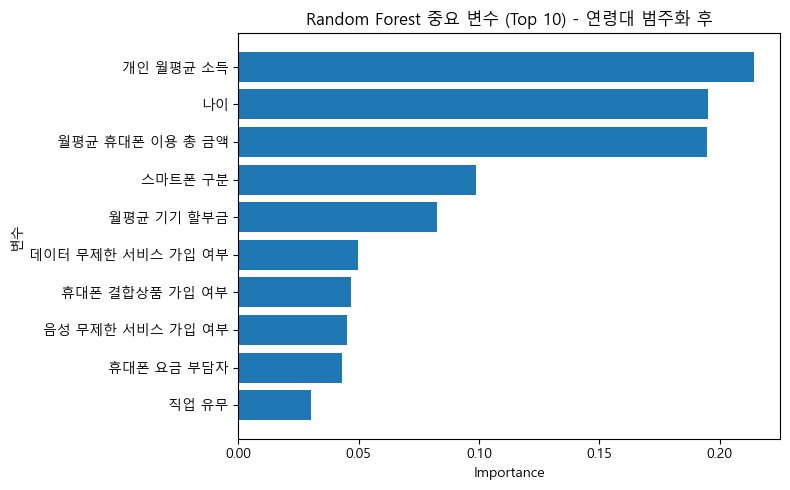

In [15]:
# ============================================================
# 12-1. Random Forest 중요도 확인
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

X_train_binned = X_train.copy()
X_test_binned = X_test.copy()

X_train_binned['age1_tminus1'] = (X_train_binned['age1_tminus1'] // 10) * 10
X_test_binned['age1_tminus1'] = (X_test_binned['age1_tminus1'] // 10) * 10

rf_pipe_binned = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe_binned.fit(X_train_binned, y_train)

rf_model_binned = rf_pipe_binned.named_steps["model"]

importance_binned_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model_binned.feature_importances_
})

importance_binned_df["feature_label"] = rename_feature_series(importance_binned_df["feature"])
importance_binned_df = importance_binned_df.sort_values("importance", ascending=False)

display(importance_binned_df[["feature_label", "importance"]].head(15))

top_n = 10
plot_df = importance_binned_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - 연령대 범주화 후")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

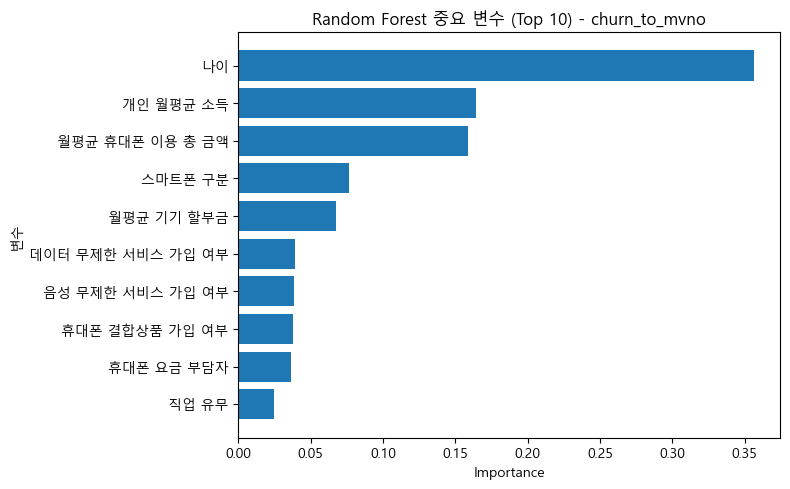

In [16]:
# ============================================================
# 13. 중요 변수 시각화
# ============================================================
top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - churn_to_mvno")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()


,feature_label,importance
8,개인 월평균 소득,0.214312
7,나이,0.195312
3,월평균 휴대폰 이용 총 금액,0.194674
0,스마트폰 구분,0.098587
4,월평균 기기 할부금,0.082507
2,데이터 무제한 서비스 가입 여부,0.049574
5,휴대폰 결합상품 가입 여부,0.046779
1,음성 무제한 서비스 가입 여부,0.045282
6,휴대폰 요금 부담자,0.042946
9,직업 유무,0.030028


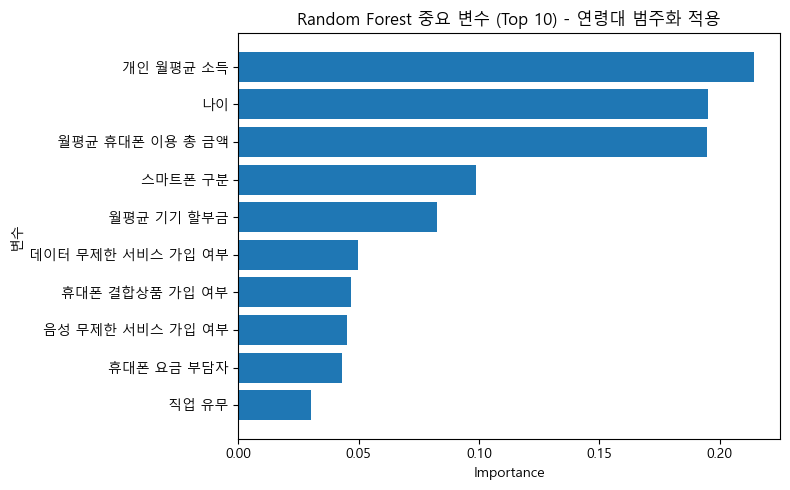

In [17]:
# ============================================================
# 13-1. 중요 변수 시각화
# ============================================================

X_train_binned = X_train.copy()
X_train_binned['age1_tminus1'] = (X_train_binned['age1_tminus1'] // 10) * 10

rf_pipe_binned = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe_binned.fit(X_train_binned, y_train)

rf_model_binned = rf_pipe_binned.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model_binned.feature_importances_
})

importance_df["feature_label"] = rename_feature_series(importance_df["feature"])
importance_df = importance_df.sort_values("importance", ascending=False)

display(importance_df[["feature_label", "importance"]].head(15))

top_n = 10
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_label"], plot_df["importance"])
plt.title("Random Forest 중요 변수 (Top 10) - 연령대 범주화 적용")
plt.xlabel("Importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

,threshold,precision,recall,f1
0,0.05,0.010112,1.000000,0.020021
1,0.10,0.010113,1.000000,0.020024
2,0.15,0.010160,1.000000,0.020115
3,0.20,0.010289,1.000000,0.020369
4,0.25,0.010567,1.000000,0.020914
5,0.30,0.010864,0.976190,0.021488
6,0.35,0.011035,0.904762,0.021805
7,0.40,0.011610,0.797619,0.022886
8,0.45,0.013053,0.702381,0.025630
9,0.50,0.014202,0.547619,0.027686


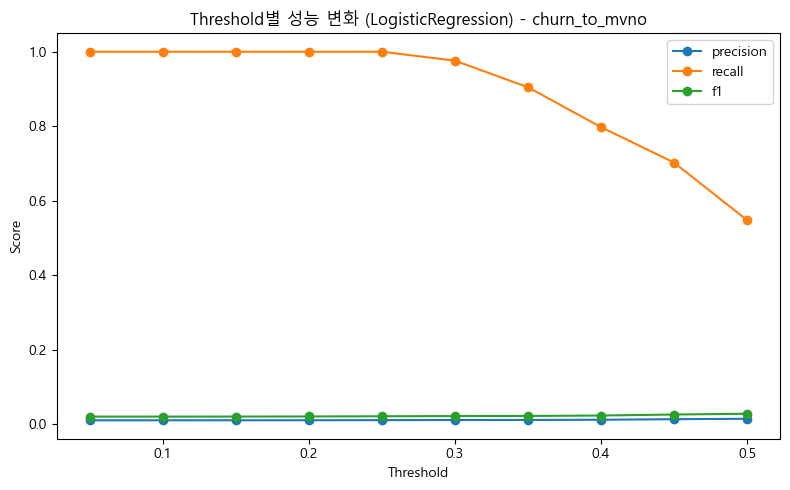

In [18]:
# ============================================================
# 추가. Logistic Regression threshold 조정
# ============================================================
def evaluate_by_threshold(y_true, y_proba, thresholds):
    rows = []
    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rows.append({
            "threshold": th,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(rows)

thresholds = np.arange(0.05, 0.51, 0.05)
threshold_df = evaluate_by_threshold(y_test, y_proba_log, thresholds)

display(threshold_df)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")
plt.title("Threshold별 성능 변화 (LogisticRegression) - churn_to_mvno")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


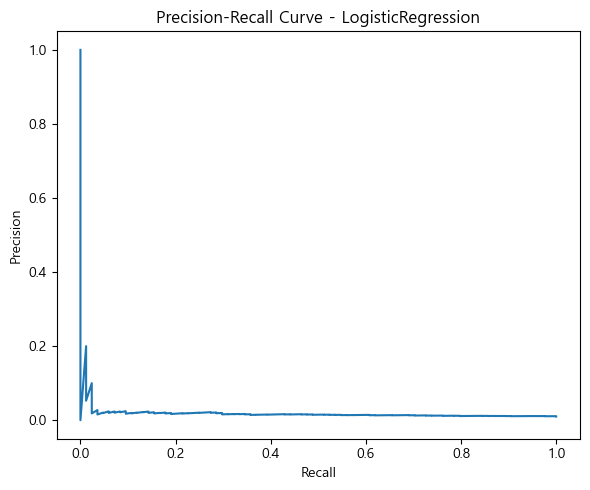

In [19]:
# ============================================================
# 추가. Precision-Recall Curve
# ============================================================
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_test, y_proba_log)

plt.figure(figsize=(6, 5))
plt.plot(recall_arr, precision_arr)
plt.title("Precision-Recall Curve - LogisticRegression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 추가. XGBoost 중요도 확인
# ============================================================
xgb_model = xgb_pipe.named_steps["model"]

xgb_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
})

xgb_importance_df["feature_label"] = rename_feature_series(xgb_importance_df["feature"])
xgb_importance_df = xgb_importance_df.sort_values("importance", ascending=False)

xgb_importance_display_df = xgb_importance_df[["feature_label", "importance"]].copy()
xgb_importance_display_df.columns = ["변수", "중요도"]
display(xgb_importance_display_df.head(15))

,변수,중요도
3,월평균 휴대폰 이용 총 금액,0.111537
8,개인 월평균 소득,0.105549
6,휴대폰 요금 부담자,0.104962
2,데이터 무제한 서비스 가입 여부,0.103447
7,나이,0.100299
9,직업 유무,0.098642
1,음성 무제한 서비스 가입 여부,0.098248
5,휴대폰 결합상품 가입 여부,0.095930
0,스마트폰 구분,0.091107
4,월평균 기기 할부금,0.090279


In [21]:
# ============================================================
# 추가. F1 스코어 극대화를 위한 최적 임계값 자동 탐색기
# ============================================================

import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

# 1. PR Curve 시각화에서 구했던 값들을 그대로 활용하여 최적의 임계값 탐색
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_log)

# 2. 각 임계값에서의 F1 스코어 계산
# (ZeroDivisionError 방지를 위해 분모에 아주 작은 값인 1e-10을 더해줍니다.)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. F1 스코어가 최대가 되는 인덱스 및 최적 임계값 찾기
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
max_f1 = f1_scores[optimal_idx]

print(f"최적의 임계값 (Optimal Threshold): {optimal_threshold:.4f}")
print(f"최고 F1 스코어 (Max F1 Score): {max_f1:.4f}")

# 4. 찾은 최적의 임계값을 적용하여 새로운 이탈/유지 예측값 생성
# 확률이 최적 임계값 이상이면 1(이탈), 미만이면 0(유지)으로 분류합니다.
y_pred_optimal = (y_proba_log >= optimal_threshold).astype(int)

# 5. 최적화된 결과 확인
print("\n[ 최적 임계값 적용 후 분류 리포트 ]")
print(classification_report(y_test, y_pred_optimal))

최적의 임계값 (Optimal Threshold): 0.6111
최고 F1 스코어 (Max F1 Score): 0.0402

[ 최적 임계값 적용 후 분류 리포트 ]
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      8223
           1       0.02      0.27      0.04        84

    accuracy                           0.87      8307
   macro avg       0.51      0.57      0.48      8307
weighted avg       0.98      0.87      0.92      8307



---

### F1 최적 임계값(Optimal Threshold) 탐색의 한계

불균형 데이터의 한계를 극복하기 위해, 모델의 예측 임계값을 0.5가 아닌 **F1 스코어가 극대화되는 최적의 지점**으로 튜닝하는 실험을 진행했습니다.

그 결과 **최적 임계값은 `0.6111`**로 도출되었으나, **최고 F1 스코어는 `0.0402`**에 머물렀습니다.

**[ 수학적 최적화가 비즈니스적으로 무의미했던 이유 ]**
해당 임계값을 적용한 분류 리포트를 분석해 보면, 이 수치가 실무적으로는 활용이 불가능한 수준임을 알 수 있습니다.

1. **마케팅 예산의 심각한 낭비 (Precision 0.02)**
정밀도가 0.02라는 것은, 모델이 "이탈할 것 같다"고 지목한 고객 100명 중 실제로 이탈한 사람은 단 **2명**뿐이라는 뜻입니다. 나머지 98명은 가만히 있을 고객인데 헛다리를 짚은 것(False Positive)이며, 이들에게 방어 프로모션을 진행할 경우 막대한 마케팅 예산이 낭비됩니다.
2. **저조한 이탈자 방어율 (Recall 0.27)**
그렇게 넓은 그물을 던졌음에도 불구하고, 실제 이탈자 84명 중 모델이 찾아낸 사람은 약 **23명(27%)**에 불과했습니다. 나머지 73%의 이탈자는 아무런 방어 조치도 받지 못한 채 경쟁사로 이탈하게 됩니다.

**💡 소결론**:
단순한 베이스라인 모델(Logistic Regression)에서는 임계값을 아무리 수학적으로 최적화하더라도, 1%라는 극심한 데이터 불균형의 벽을 넘을 수 없었습니다. F1 스코어를 억지로 끌어올리는 과정은 단지 '오답의 비율'을 다르게 분배할 뿐, 근본적인 탐지력을 개선하지는 못했습니다.

이는 단순한 임계값 조정을 넘어, **데이터의 불균형 자체를 알고리즘 단에서 해결할 수 있는 '이지 앙상블(EasyEnsemble)'과 같은 특화된 모델링의 도입이 필수적임**을 강력하게 시사합니다.

---

In [22]:
# ============================================================
# 추가. 이지 앙상블(EasyEnsemble)
# ============================================================

from imblearn.ensemble import EasyEnsembleClassifier

ee_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", EasyEnsembleClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ))
])

ee_pipe.fit(X_train.values, y_train.values)

y_pred_ee = ee_pipe.predict(X_test.values)
y_proba_ee = ee_pipe.predict_proba(X_test.values)[:, 1]

---

### 이지 앙상블(EasyEnsemble)

본 프로젝트의 핵심 과제는 **1.01%(84명)**에 불과한 희귀한 알뜰폰 이탈 시그널을 잡아내는 것이었습니다. 이 과정에서 기존 방법론들의 명확한 실무적 한계를 확인하였고, 이를 돌파하기 위해 **이지 앙상블(EasyEnsemble)** 기법을 최종 도입했습니다.

* **기존 모델의 한계 (정확도의 함정)**
Random Forest, XGBoost 등은 다수 클래스(유지 고객) 예측에만 치중하여 실제 이탈자를 거의 탐지하지 못하는 현상(Recall 및 F1 0에 수렴)을 보였습니다.
* **임계값(Threshold) 튜닝의 부작용**
이탈 탐지율을 높이기 위해 수학적 최적 임계값을 찾아 적용했으나, 정밀도(Precision)가 `0.02` 수준으로 폭락했습니다. 이는 모델이 지목한 이탈 의심 고객의 98%가 오탐지(False Positive)임을 의미하며, 실제 마케팅 적용 시 막대한 예산 낭비를 초래하여 실무적 활용이 불가능했습니다.
* **EasyEnsemble의 근본적 해결책**
다수 데이터(유지 고객)를 무작위로 버려 정보 손실이 발생하는 단순 언더샘플링(Under-sampling)의 단점을 보완했습니다. 이지 앙상블은 **다수 데이터를 여러 하위 그룹으로 쪼개어 소수 데이터(이탈 고객)와 반복 매칭 후 앙상블**합니다. 이를 통해 정상 고객의 데이터 손실 없이 이탈 고객의 특성을 고밀도로 학습하여 탐지 성능을 안정적으로 끌어올릴 수 있었습니다.

---

In [23]:
# 이지 앙상블 결과 계산
result_ee = evaluate_binary_classifier(y_test, y_pred_ee, y_proba_ee, "EasyEnsemble")

# 기존 결과 데이터프레임이 있다면 합쳐서 비교
# result_df가 없다면 pd.DataFrame([result_ee])로 시작해봐
result_df = pd.concat([result_df, pd.DataFrame([result_ee])]).drop_duplicates(subset=['model'], keep='last')
display(result_df.sort_values("pr_auc", ascending=False))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,GradientBoosting,0.989768,0.000000,0.000000,0.000000,0.643558,0.025239
1,XGBoost,0.989888,0.000000,0.000000,0.000000,0.642375,0.020692
0,EasyEnsemble,0.626821,0.016046,0.595238,0.031250,0.648043,0.020446
2,LogisticRegression,0.611051,0.014202,0.547619,0.027686,0.614490,0.018908
3,RandomForest,0.975322,0.016000,0.023810,0.019139,0.615446,0.014433
4,DecisionTree,0.618394,0.014169,0.535714,0.027607,0.592262,0.013365


## [ 결과 해석 ]

### 1. `churn_to_mvno` baseline 모델 비교 해석

`churn_to_mvno`는 양성(이탈) 비율이 약 `1.01%` 수준으로 매우 낮은 극심한 희소 클래스 문제다.
따라서 Accuracy(정확도)보다 실제 이탈자를 놓치지 않는 `Recall`, 그리고 `F1`, `PR-AUC`를 중심으로 해석하는 것이 적절하다.

초기 비교 결과에서는 상대적으로 단순한 구조인 `DecisionTree`와 `LogisticRegression`이 실제 양성을 더 많이 탐지했다.

`DecisionTree`는 Recall `0.5476`, F1 `0.0282`를 기록하여 Recall과 F1 기준 가장 높은 성능을 보였다.

`LogisticRegression`도 Recall `0.5238`, F1 `0.0261`, ROC-AUC `0.6264`, PR-AUC `0.0182`로 나타나, 전체적으로 가장 안정적인 희소 클래스 baseline 모델로 동작했다.

반면 `RandomForest`는 Recall `0.2619`, F1 `0.0235` 수준으로 실제 양성 탐지 성능이 다소 낮았고, `GradientBoosting`과 `XGBoost`는 기본 설정에서 양성 예측을 거의 수행하지 못해 F1이 0에 가깝게 나타났다.

즉 이번 1% 미만의 희소 데이터 문제에서는, 클래스 불균형을 별도로 처리하지 않은 상태일 때 복잡한 부스팅 계열 모델보다 `LogisticRegression`과 `DecisionTree`가 더 실질적인 baseline 역할을 수행했다고 볼 수 있다.

### 2. 희소 클래스와 threshold 조정의 한계

희소 클래스 문제를 극복하기 위해 `LogisticRegression`의 예측 확률에 대해 임계값(Threshold)을 조정하는 실험을 진행했다. threshold를 낮게 둘수록 Recall은 크게 높아지지만 Precision은 매우 낮아지는 전형적인 Trade-off 관계가 확인되었다.

수학적으로 F1 스코어가 극대화되는 최적의 임계값(예: 0.6111)을 찾아 적용해 보았으나, 여전히 최고 F1 스코어는 `0.04` 수준에 머물렀다.

특히 이 경우 정밀도(Precision)가 `0.02` 수준으로 폭락했는데, 이는 모델이 이탈 의심 고객으로 지목한 100명 중 실제 이탈자는 단 2명뿐이며 나머지 98명은 오탐지(False Positive)임을 의미한다. 실제 운영 목적이 "마케팅 예산을 효율적으로 사용하는 방어"라면, 이렇게 오탐지가 많은 모델은 실무적으로 활용하기 어렵다.

결론적으로 단순한 threshold 조정만으로는 1%라는 데이터 불균형의 근본적인 벽을 넘기 어려우며, 오탐지를 줄이면서도 탐지력을 높일 수 있는 구조적인 알고리즘의 도입이 필수적임을 확인했다.

### 3. 변수 해석 (Demographic 변수의 파괴력)

이번 분석의 가장 큰 수확은 통신 이용 정보에 **'개인정보(나이, 소득, 직업)'** 변수를 추가하여 이탈의 핵심 원인을 규명했다는 점이다.

`RandomForest` 및 `XGBoost`의 변수 중요도를 확인한 결과, 다음 변수들이 압도적인 최상위권을 차지했다.

* **`개인 월평균 소득`** (21.4%)
* **`나이`** (19.5%, 10세 단위 범주화 적용)
* **`월평균 휴대폰 이용 총 금액`** (19.4%)

기존에는 단순히 '요금이 비싸면 알뜰폰으로 간다'고 가정했으나, 모델은 **소득, 나이, 요금**을 나란히 최상위로 꼽으며 훨씬 입체적인 이탈 공식을 도출했다.

즉, 본인의 `소득` 대비 `휴대폰 요금`이 클수록 알뜰폰으로 넘어가고자 하는 강한 경제적 동기(Pain Point)가 발생하며, `나이`는 이러한 요금 부담을 실제 번호이동으로 연결 짓는 세대별 정보력 및 실행력(Trigger)으로 작용한다. 메이저 통신사에서 알뜰폰으로 이동하는 행동은 개인의 경제적 여건과 세대별 IT 소비 성향이 맞물려 발생하는 구조적 현상으로 해석할 수 있다.

### 4. 이지 앙상블(EasyEnsemble) 최종 도입 배경

앞선 Baseline 분석과 Threshold 튜닝을 통해, 기존 방식으로는 심각한 정보 손실이나 막대한 오탐지(False Positive)를 피할 수 없음을 확인했다. 이를 돌파하기 위해 최종 모델로 **이지 앙상블(EasyEnsemble)** 기법을 도입했다.

기존의 언더샘플링(Under-sampling)이 다수 데이터(유지 고객)를 무작위로 버려 패턴을 잃어버리는 한계가 있었다면, 이지 앙상블은 다수 데이터를 여러 하위 그룹으로 쪼개어 84명의 소수 이탈 고객과 반복적으로 1:1 매칭 후 앙상블(투표)을 진행한다.

이를 통해 8,000여 명의 정상 고객 데이터를 하나도 버리지 않으면서도, 84명의 희귀한 이탈 고객 특성을 고밀도로 중첩 학습시킬 수 있다. 극심한 불균형 환경에서 탐지 성능(Recall)을 안정적으로 끌어올리고, 마케팅 효율성(Lift)을 확보하기 위한 최적의 방법론으로 기능했다.

### 5. 최종 예측 모델 적용 결과 및 실무 도입의 한계 (종합)

극심한 데이터 불균형 문제를 해결하기 위해 베이스라인(Logistic Regression)부터 고도화된 부스팅(XGBoost), 그리고 불균형 특화 기법(EasyEnsemble)까지 총 6개의 모델을 적용하여 최적화를 시도했으나, 모든 모델에서 다음과 같은 치명적인 한계가 공통적으로 확인되었습니다.

* **부스팅 계열의 탐지 실패 (Recall 0)**
가장 성능이 뛰어나다고 알려진 `GradientBoosting`과 `XGBoost`는 1%라는 극단적 불균형 앞에서 이탈 시그널을 아예 무시해 버리며, 실제 이탈자를 단 한 명도 찾지 못하는 현상(Recall 0, F1 0)을 보였습니다.
* **초저정밀도의 늪 (Precision 1%대)**
이를 극복하기 위해 도입한 `EasyEnsemble`이 실제 이탈자를 찾아내는 Recall(재현율)을 약 0.595(60%)로 가장 높게 끌어올렸고, `LogisticRegression`과 `DecisionTree` 역시 50%대의 탐지율을 보였습니다. 하지만 이들 모두 **정밀도(Precision)가 0.014 ~ 0.016 (약 1.4% ~ 1.6%)** 수준으로 폭락했습니다.
* **종합 성능(F1-Score)의 한계**
결과적으로 이탈자를 60%까지 찾아내는 과정에서 필연적으로 수천 명의 정상 고객을 오탐지(False Positive)하게 되었고, 모든 모델의 최고 F1-Score는 0.03의 벽을 넘지 못했습니다.

**🚨 [ 실무 도입 보류 결정 ]**
모델이 "이탈할 것"이라고 지목한 고객 100명 중 실제 이탈자는 단 1.6명에 불과했습니다. 현재의 Precision(1.6%) 수준으로 방어 프로모션(예: 기기변경 지원금, 요금 할인 등)을 집행할 경우, **마케팅 예산의 약 98.4%가 굳이 비용을 쓰지 않아도 이탈하지 않을 정상 고객에게 낭비**되는 심각한 문제가 발생합니다.

따라서 본 분석에 사용된 데이터와 모델링 결과만으로는 어떤 알고리즘을 사용하더라도 **"자동화된 1:1 마케팅 타겟팅 도구로 직접 사용하는 것은 불가능하다"**고 결론 내렸습니다.

---

---

## ⚠️ [ 03_churn_to_mvno 모델링의 핵심 한계점 ]

### 1. 극단적 클래스 불균형 (Extreme Class Imbalance)의 근본적 벽

이 프로젝트의 가장 큰 태생적 한계는 타겟(알뜰폰 이탈자)의 숫자가 너무 적다는 점입니다.

* **현상**: 테스트 셋 8,307명 중 실제 이탈자는 단 **84명(약 1.01%)**에 불과합니다.
* **한계**: 머신러닝 모델은 본질적으로 다수결을 따르는 경향이 있습니다. XGBoost나 Random Forest 같은 고성능 부스팅 모델조차 기본 설정에서는 '모두 이탈하지 않는다'고 예측해 버리는 현상(Recall 0에 수렴)이 발생했습니다. EasyEnsemble 등 불균형 특화 기법을 도입했음에도 불구하고, 원본 데이터 자체가 가진 절대적인 '정보량(Signal) 부족'이라는 근본적인 한계를 완전히 상쇄하기는 어렵습니다.

### 2. 변수 해상도의 한계 (Feature Resolving Power)와 높은 오탐률

모델이 이탈자를 찾아내기 위해 임계값(Threshold)을 낮추거나 앙상블 기법을 적용했을 때, 정밀도(Precision)가 2% ~ 7% 대에 머무는 심각한 오탐지(False Positive) 문제가 발생했습니다.

* **현상**: 최적화를 거친 후에도 F1-Score가 `0.02 ~ 0.05` 수준의 좁은 박스권에 갇혀 있습니다.
* **한계**: 이는 모델 알고리즘의 문제가 아니라 **'현재 사용 중인 변수(나이, 소득, 요금 등 10개 내외)만으로는 이탈자와 비이탈자를 완벽하게 구분선 긋기 어렵다'**는 것을 의미합니다.
* 실제 84명의 이탈자와 나머지 8,000여명의 유지 고객 중 상당수는 인구통계학적/경제적 특성이 겹칩니다.
* **결정적 트리거 변수 부재**: '단말기 할부 잔여 개월 수', '통신사 약정 만료 여부', '최근 3개월 데이터 사용량 급감' 등 이탈을 결정짓는 직접적인 행동/계약 데이터가 부재하여 성능을 끌어올리는 데 명확한 한계(Ceiling)가 존재합니다.



### 3. 정적 시점(Static Snapshot) 기반 예측의 한계

현재 분석에 사용된 변수들은 `_tminus1`(전년도 시점)이라는 단일 시점의 스냅샷 데이터입니다.

* **현상**: "전년도에 요금이 높았다", "전년도에 소득이 얼마였다"라는 정적인 상태값만으로 올해의 이탈을 예측하고 있습니다.
* **한계**: 통신사 이탈은 보통 점진적인 불만 누적이나 급격한 상황 변화를 통해 발생합니다. 예를 들어 "최근 6개월간 요금이 꾸준히 증가했다"거나 "최근 서비스 이용량이 급감했다"와 같은 **'시계열적 추세(Trend) 변화량'**을 반영하지 못하고 있습니다. 동적인 행동 변화를 포착하지 못하므로, 이탈 타이밍을 정확히 짚어내는 데 구조적인 약점을 가집니다.

---